**LOADING THE LIBRARIES**

In [1]:
from bs4 import BeautifulSoup
import requests 
import selenium
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.common.exceptions import StaleElementReferenceException
import time

**LOADING THE WEBSITE USING WEBDRIVER**

In [4]:
website = 'https://www.opentable.com/r/vetro-by-russos-on-the-bay-howard-beach?corrid=bef7aba3-3539-4665-8580-4e5f6be8f71a&avt=eyJ2IjoyLCJtIjoxLCJwIjowLCJzIjowLCJuIjowfQ&p=2&sd=2024-11-30T19%3A00%3A00'

driver = webdriver.Chrome()
driver.get(website)

**SCRAPING REVIEWS**

In [17]:
review_list = []

while True:
    reviews = driver.find_elements(By.XPATH, '//li[@class="afkKaa-4T28-"]//div[@class="_6rFG6U7PA6M-"]//span[@class="l9bbXUdC9v0- ZatlKKd1hyc- ukvN6yaH1Ds-"]') 
    for i in reviews: 
        review_list.append(i.text)
    try: 
        next_button = driver.find_element(By.XPATH, '//div[@class="TkpxbcBbu80-"]//a[@aria-label="Go to the next page"]')
        driver.execute_script("arguments[0].style.border='3px solid red'", next_button)
        next_button.click()
        time.sleep(3)
    except StaleElementReferenceException: 
        print("StaleElementReferenceException occurred. Refreshing the page.")
        driver.refresh()
        time.sleep(4)
    except:
        print("No more pages.")
        break



StaleElementReferenceException occurred. Refreshing the page.
No more pages.


**SCRAPING DATES**

In [ ]:
dates_list = []

while True:
    dates = driver.find_elements(By.XPATH, '//li[@class="afkKaa-4T28-"]//div[@class="MpiILQAMSSg-"]//div[@class="yuQYBV659bs- C7Tp-bANpE4-"]//p[@class="iLkEeQbexGs-"]') 
    for i in dates: 
        dates_list.append(i.text)
    try: 
        next_button = driver.find_element(By.XPATH, '//div[@class="TkpxbcBbu80-"]//a[@aria-label="Go to the next page"]')
        driver.execute_script("arguments[0].style.border='3px solid red'", next_button)
        next_button.click()
        time.sleep(3)
    except StaleElementReferenceException: 
        print("StaleElementReferenceException occurred. Refreshing the page.")
        driver.refresh()
        time.sleep(4)
    except:
        print("No more pages.")

**SCRAPING RATINGS**

In [9]:
ratings_list = []

while True:
    ratings = driver.find_elements(By.XPATH, '//li[@class="-k5xpTfSXac-"]')
    for rating in ratings: 
        ratings_list.append(rating.text)
    try: 
        next_button = driver.find_element(By.XPATH, '//div[@class="TkpxbcBbu80-"]//a[@aria-label="Go to the next page"]')
        driver.execute_script("arguments[0].style.border='3px solid red'", next_button)
        next_button.click()
        time.sleep(3)
    except StaleElementReferenceException: 
        print("StaleElementReferenceException occurred. Refreshing the page.")
        driver.refresh()
        time.sleep(4)
    except:
        print("No more pages.")
        break

StaleElementReferenceException occurred. Refreshing the page.
No more pages.


**WRITING DATES TO TEXT FILE**

In [89]:
with open('dates.txt', 'w', encoding='utf-8') as file:
    for dates in dates_list:
        file.write(dates + '\n')  # Write each date followed by a new line

print("Data saved to dates.txt")

Data saved to dates.txt


**WRITING REVIEWS TO TEXT FILE**

In [20]:
with open('reviews.txt', 'w', encoding='utf-8') as file:
    for review in review_list:
        file.write(review + '\n')  # Write each review followed by a new line

print("Data saved to reviews.txt")

Data saved to reviews.txt


**WRITING RATINGS TO TEXT FILE**

In [10]:
ratings_dict = {}

# Group the ratings in chunks of 4 (since each review has 4 lines)
for i in range(0, len(ratings_list), 4):
    review_key = (f"Review {i//4 + 1}") 
    ratings_dict[review_key] = ratings_list[i:i+4]

with open("ratings.txt", "w", encoding="utf-8") as file:
    for key, value in ratings_dict.items():
        file.write(f"{key}:\n")  # Write the review key
        for rating in value:
            file.write(f"  {rating}\n")  # Write each rating indented
        file.write("\n")  # Add a blank line between reviews

**READING REVIEWS FROM TEXT FILE**

In [1]:
with open("reviews.txt", "r", encoding="utf-8") as file:
    review_list = [line.strip() for line in file]

**READING DATES FROM TEXT FILE**

In [33]:
# Read the dates from the file into a list
with open('dates.txt', 'r', encoding='utf-8') as file:
    dates_list = file.readlines()  # Reads all lines into a list

# Strip whitespace and newline characters from each date
dates_list = [date.strip() for date in dates_list]

# Print the list of dates
for i in dates_list:
    print(i)

Dined 7 days ago
Dined on December 2, 2024
Dined on November 29, 2024
Dined on November 28, 2024
Dined on November 17, 2024
Dined on November 17, 2024
Dined on November 17, 2024
Dined on November 17, 2024
Dined on November 10, 2024
Dined on November 10, 2024
Dined 7 days ago
Dined on December 2, 2024
Dined on November 29, 2024
Dined on November 28, 2024
Dined on November 17, 2024
Dined on November 17, 2024
Dined on November 17, 2024
Dined on November 17, 2024
Dined on November 10, 2024
Dined on November 10, 2024
Dined on November 4, 2024
Dined on October 18, 2024
Dined on October 14, 2024
Dined on October 13, 2024
Dined on September 29, 2024
Dined on September 28, 2024
Dined on September 23, 2024
Dined on September 22, 2024
Dined on September 21, 2024
Dined on September 9, 2024
Dined on September 8, 2024
Dined on September 8, 2024
Dined on September 8, 2024
Dined on August 31, 2024
Dined on August 31, 2024
Dined on August 31, 2024
Dined on August 29, 2024
Dined on August 29, 2024
Dined

**PROMPT ENGINEERING MODULE**

In [12]:
from groq import Groq
import os

In [14]:
client = Groq(
    api_key=os.environ.get("GROQ_API_KEY"),
)

In [37]:
def ask(message, sys_message="You are an expert analyst of restaurant food and staff reviews. You are adept at distinguishing between positive, negative and neutral reviews. You are also capable of segregating reviews related to staff and food, and avoid mixing the reviews",
         model="llama3-8b-8192"):

    # Construct the messages list for the chat
    messages = [
        {"role": "system", "content": sys_message},
        {"role": "user", "content": message}
    ]

    # Send the messages to the model and get the response
    response = client.chat.completions.create(model=model, messages=messages)

    # Return the content of the model's response
    return response.choices[0].message.content

categorized_reviews = {"positive": [], "negative": [], "neutral": []}

for review in review_list:
    analysis = ask(review)
    print(f"Review: {review}")
    print(f"Analysis: {analysis}\n")
    
    # Categorize based on response
    if "positive" in analysis.lower():
        categorized_reviews["positive"].append(review)
    elif "negative" in analysis.lower():
        categorized_reviews["negative"].append(review)
    else:
        categorized_reviews["neutral"].append(review)

# Output the categorized reviews
print("Categorized Reviews:")
for category, reviews in categorized_reviews.items():
    print(f"{category.capitalize()} Reviews:")
    for rev in reviews:
        print(f" - {rev}")
    print()

Review: The food is always amazing! You can’t go wrong with Russo’s!!!
Analysis: This review is highly positive, and it's specifically praising the food at Russo's. The reviewer uses superlatives such as "always amazing" and "you can't go wrong", indicating a very high level of satisfaction with the culinary experience.

Review: The service and the food were outstanding! My husband had the skirt steak and I had the pork milanese. Would return again!
Analysis: This review is **POSITIVE**!

The reviewer explicitly mentions that the service and food were "outstanding", which is a very strong positive statement. Additionally, they specifically mention the dishes they ordered and enjoyed, which suggests that they were impressed with the culinary offerings. The reviewer also expresses their intention to return, which indicates a high level of satisfaction.

Review: Went for Thanksgiving and had the preset menu. Food ambience and service was excellent. I will definitely be back.
Analysis: Thi

**TESTING SYSTEM PROMPT**

In [36]:
ask('Hi. What are you?')

"Nice to meet you! I'm an expert analyst of restaurant food and staff reviews. I've been trained to distinguish between positive, negative, and neutral reviews, and I'm great at separating reviews related to staff and food, so you don't have to worry about mixing them up. I can help you understand what customers are saying about their dining experiences and provide insights to improve your restaurant's reputation and service."

**WRITING CODE ONTO JSON FILE**

In [40]:
import json

with open('categorized_reviews.json', 'w', encoding='utf-8') as file:
    json.dump(categorized_reviews, file, indent=4, ensure_ascii=False)

print("Categorized reviews saved to categorized_reviews.json")

Categorized reviews saved to categorized_reviews.json


**DASHBOARD/GUI USING STREAMLIT**

In [2]:
import streamlit as st
import json

# Load the categorized reviews JSON file
def load_reviews(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        return json.load(file)

# Streamlit app
st.title("Restaurant Review Analyzer")

# Sidebar for navigation
st.sidebar.title("Navigation")
page = st.sidebar.radio("Go to", ["Home", "View Reviews"])

# Load reviews
reviews_file = "categorized_reviews.json"
categorized_reviews = load_reviews(reviews_file)

# Home Page
if page == "Home":
    st.header("Welcome to the Restaurant Review Analyzer!")
    st.write(
        "This dashboard categorizes reviews into positive, neutral, and negative based on food quality."
    )
    st.write("Use the navigation menu to explore the reviews.")

# View Reviews Page
elif page == "View Reviews":
    st.header("Categorized Reviews")
    category = st.selectbox("Select Category", ["positive", "neutral", "negative"])

    if categorized_reviews.get(category):
        st.subheader(f"{category.capitalize()} Reviews:")
        for i, review in enumerate(categorized_reviews[category], 1):
            st.write(f"{i}. {review}")
    else:
        st.write("No reviews available for this category.")


2024-12-13 19:35:58.575 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-12-13 19:35:58.711 
  command:

    streamlit run C:\Users\Hassan\AppData\Roaming\Python\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2024-12-13 19:35:58.712 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-12-13 19:35:58.713 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-12-13 19:35:58.713 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-12-13 19:35:58.714 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-12-13 19:35:58.714 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-12-13 19:35:58.715 Thr

**COMPETITOR ANALYSIS**

In [21]:
website_new = 'https://www.opentable.com/r/il-toscano-douglaston?corrid=6b0c8cbf-f13d-44ee-bd17-c12da0c81af0&avt=eyJ2IjoyLCJtIjoxLCJwIjowLCJzIjowLCJuIjowfQ&p=2&sd=2024-12-13T19%3A00%3A00'

driver_new = webdriver.Chrome()
driver_new.get(website_new)

**SCRAPING COMPETITOR RATINGS**

In [ ]:
ratings_competitor_list = []

while True:
    ratings_competitor = driver_new.find_elements(By.XPATH, '//li[@class="-k5xpTfSXac-"]')
    for rating in ratings_competitor: 
        ratings_competitor_list.append(rating.text)
    try: 
        next_button = driver_new.find_element(By.XPATH, '//div[@class="TkpxbcBbu80-"]//a[@aria-label="Go to the next page"]')
        driver_new.execute_script("arguments[0].style.border='3px solid red'", next_button)
        next_button.click()
        time.sleep(3)
    except StaleElementReferenceException: 
        print("StaleElementReferenceException occurred. Refreshing the page.")
        driver_new.refresh()
        time.sleep(4)
    except:
        print("No more pages.")
        break

**WRITING COMPETITOR RATINGS TO TEXT FILE**

In [24]:
ratings_competitor_dict = {}

# Group the ratings in chunks of 4 (since each review has 4 lines)
for i in range(0, len(ratings_competitor_list), 4):
    review_key_comp = (f"Review {i//4 + 1}") 
    ratings_competitor_dict[review_key_comp] = ratings_competitor_list[i:i+4]

with open("ratings_competitor.txt", "w", encoding="utf-8") as file:
    for key, value in ratings_competitor_dict.items():
        file.write(f"{key}:\n")  # Write the review key
        for rating in value:
            file.write(f"  {rating}\n")  # Write each rating indented
        file.write("\n")  # Add a blank line between reviews

In [26]:
ratings_dict = {}

with open("ratings.txt", "r", encoding="utf-8") as file:
    lines = file.readlines()

review_key = None
ratings_list = []

for line in lines:
    line = line.strip()
    if line.endswith(":"):  # This indicates a review key (e.g., "Review 1:")
        if review_key is not None:
            ratings_dict[review_key] = ratings_list  # Save the previous review
        review_key = line[:-1]  # Remove the colon at the end
        ratings_list = []  # Reset the ratings list for the new review
    elif line:  # If line is not empty, add to ratings list
        ratings_list.append(line.strip())
        
# Add the last review if file doesn't end with a blank line
if review_key is not None:
    ratings_dict[review_key] = ratings_list


{'Review 1': ['Overall 5', 'Food 5', 'Service 5', 'Ambience 4'], 'Review 2': ['Overall 5', 'Food 5', 'Service 5', 'Ambience 5'], 'Review 3': ['Overall 5', 'Food 5', 'Service 4', 'Ambience 4'], 'Review 4': ['Overall 5', 'Food 4', 'Service 5', 'Ambience 5'], 'Review 5': ['Overall 5', 'Food 5', 'Service 5', 'Ambience 5'], 'Review 6': ['Overall 5', 'Food 4', 'Service 5', 'Ambience 5'], 'Review 7': ['Overall 5', 'Food 5', 'Service 5', 'Ambience 5'], 'Review 8': ['Overall 5', 'Food 5', 'Service 5', 'Ambience 5'], 'Review 9': ['Overall 4', 'Food 4', 'Service 4', 'Ambience 4'], 'Review 10': ['Overall 5', 'Food 4', 'Service 5', 'Ambience 5'], 'Review 11': ['Overall 5', 'Food 5', 'Service 5', 'Ambience 4'], 'Review 12': ['Overall 5', 'Food 5', 'Service 5', 'Ambience 5'], 'Review 13': ['Overall 5', 'Food 5', 'Service 4', 'Ambience 4'], 'Review 14': ['Overall 5', 'Food 4', 'Service 5', 'Ambience 5'], 'Review 15': ['Overall 5', 'Food 5', 'Service 5', 'Ambience 5'], 'Review 16': ['Overall 5', 'Food 

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
# Helper function to extract ratings from the reviews (both dictionaries)
def extract_ratings(ratings_dict):
    extracted_data = {
        "Overall": [],
        "Food": [],
        "Service": [],
        "Ambience": []
    }
    
    for review in ratings_dict.values():
        for line in review:
            category, rating = line.split()  # Split into category and rating
            extracted_data[category].append(int(rating))
    
    return extracted_data


In [39]:
vetro_ratings = extract_ratings(ratings_dict)
competitor_ratings = extract_ratings(ratings_competitor_dict)

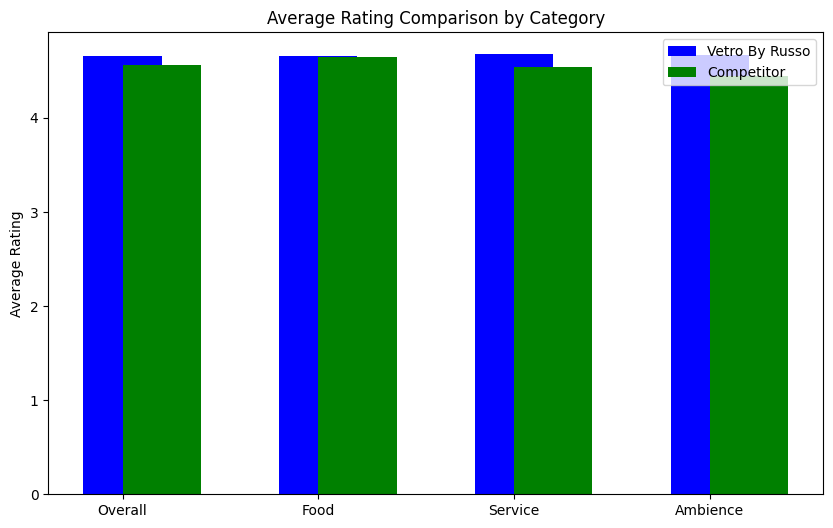

In [33]:
# Plot 1: Compare Average Ratings for each category using a Bar Chart
categories = ["Overall", "Food", "Service", "Ambience"]
avg_old = [sum(vetro_ratings[category]) / len(vetro_ratings[category]) for category in categories]
avg_competitor = [sum(competitor_ratings[category]) / len(competitor_ratings[category]) for category in categories]

plt.figure(figsize=(10, 6))
x = range(len(categories))
plt.bar(x, avg_old, width=0.4, label='Vetro By Russo', color='blue', align='center')
plt.bar(x, avg_competitor, width=0.4, label='Competitor', color='green', align='edge')
plt.xticks(x, categories)
plt.title('Average Rating Comparison by Category')
plt.ylabel('Average Rating')
plt.legend()
plt.show()

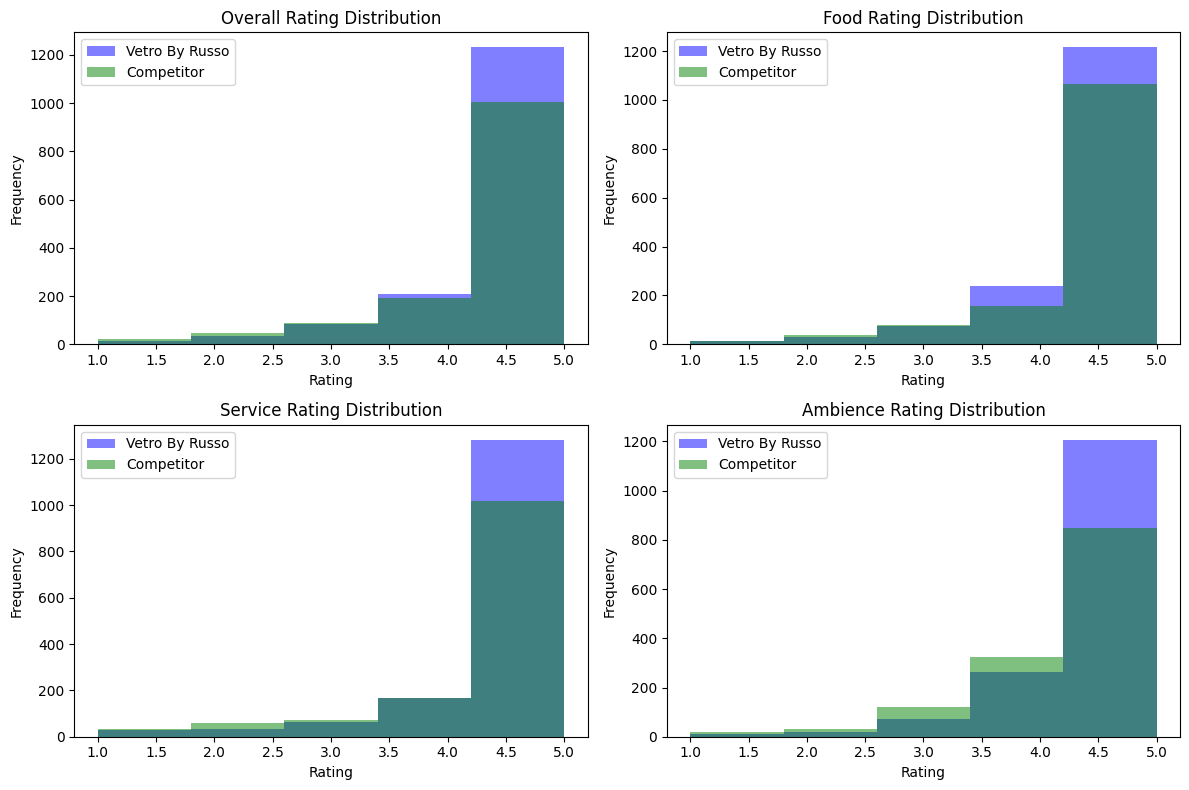

In [34]:
# Plot 2: Rating Distribution for each category using Histograms
plt.figure(figsize=(12, 8))
for i, category in enumerate(categories):
    plt.subplot(2, 2, i+1)
    plt.hist(vetro_ratings[category], alpha=0.5, label='Vetro By Russo', bins=5, range=(1, 5), color='blue')
    plt.hist(competitor_ratings[category], alpha=0.5, label='Competitor', bins=5, range=(1, 5), color='green')
    plt.title(f'{category} Rating Distribution')
    plt.xlabel('Rating')
    plt.ylabel('Frequency')
    plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

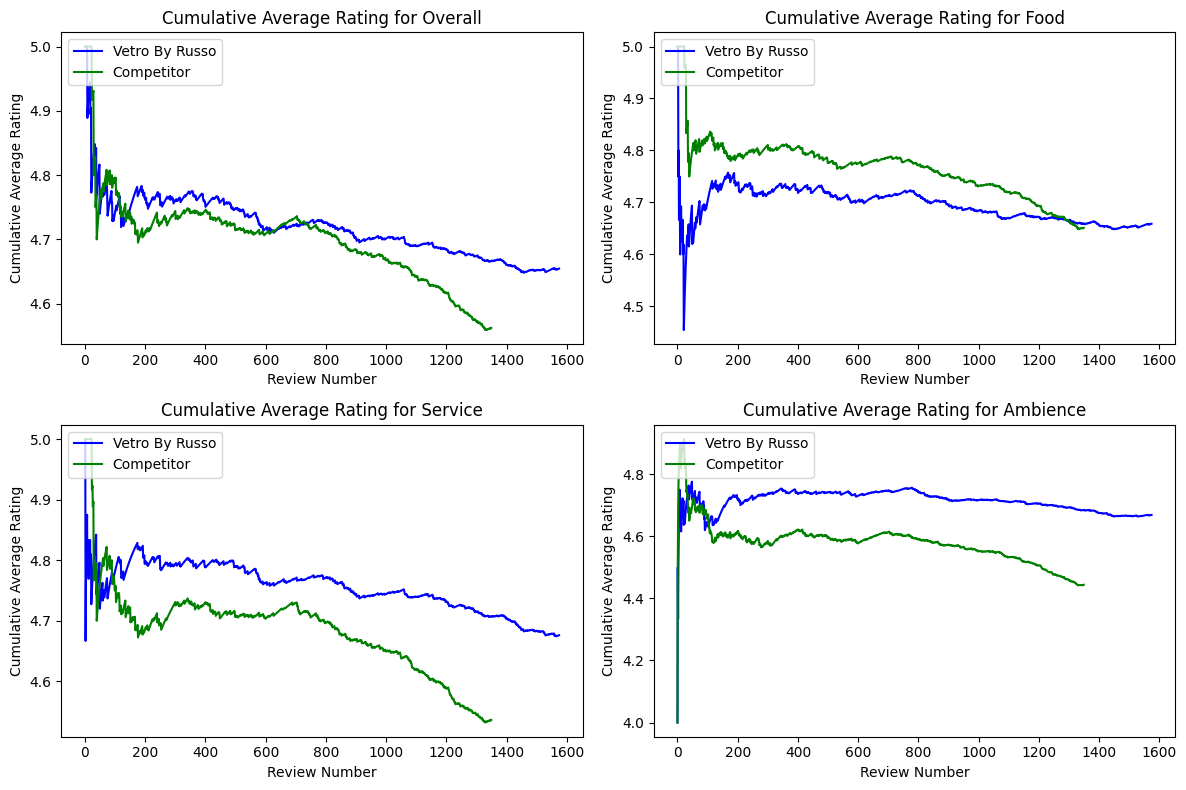

In [36]:
# Plot 4: Comparison Over Reviews (Cumulative Average by Category)
cumulative_avg_old = {
    category: [sum(vetro_ratings[category][:i+1]) / (i+1) for i in range(len(vetro_ratings[category]))]
    for category in categories
}
cumulative_avg_competitor = {
    category: [sum(competitor_ratings[category][:i+1]) / (i+1) for i in range(len(competitor_ratings[category]))]
    for category in categories
}

plt.figure(figsize=(12, 8))
for i, category in enumerate(categories):
    plt.subplot(2, 2, i+1)
    plt.plot(cumulative_avg_old[category], label='Vetro By Russo', color='blue')
    plt.plot(cumulative_avg_competitor[category], label='Competitor', color='green')
    plt.title(f'Cumulative Average Rating for {category}')
    plt.xlabel('Review Number')
    plt.ylabel('Cumulative Average Rating')
    plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


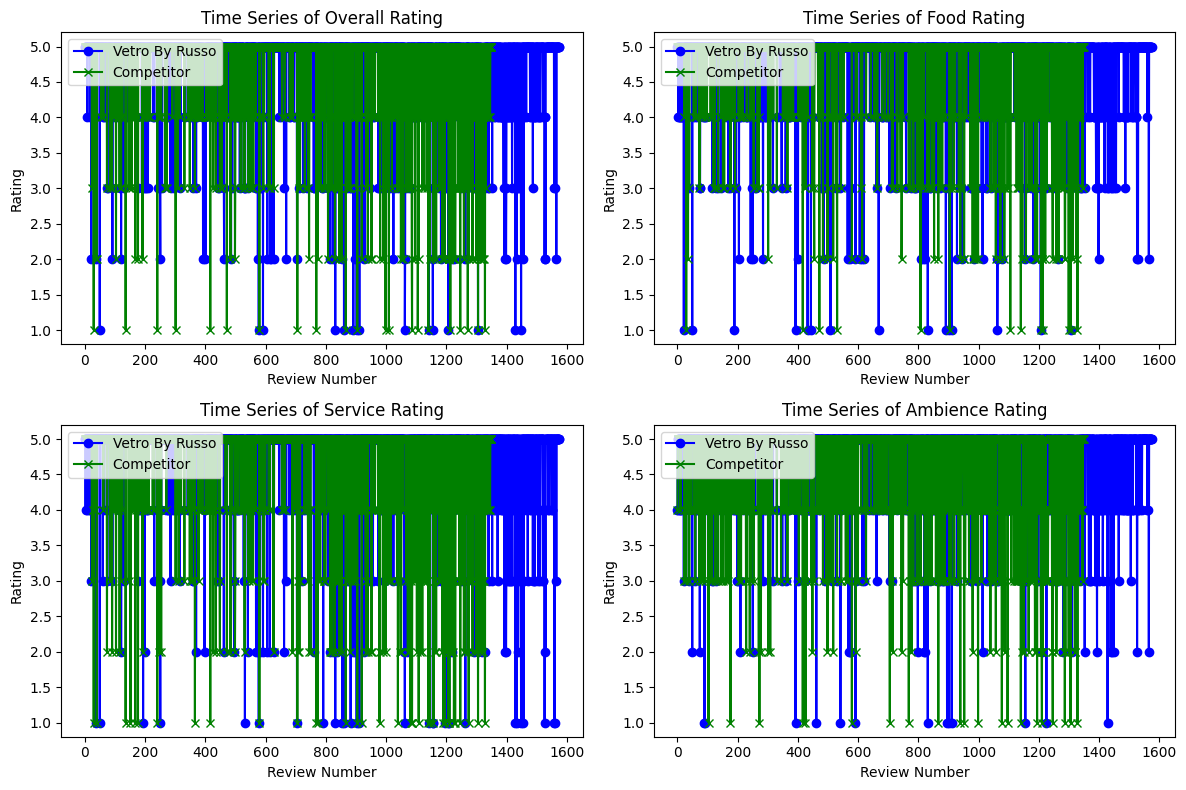

In [40]:
plt.figure(figsize=(12, 8))
for i, category in enumerate(["Overall", "Food", "Service", "Ambience"]):
    plt.subplot(2, 2, i+1)
    plt.plot(vetro_ratings[category], label='Vetro By Russo', color='blue', marker='o')
    plt.plot(competitor_ratings[category], label='Competitor', color='green', marker='x')
    plt.title(f'Time Series of {category} Rating')
    plt.xlabel('Review Number')
    plt.ylabel('Rating')
    plt.legend(loc='upper left')

plt.tight_layout()
plt.show()